# ISEN 427 Final Report
### Fletcher Newman | April 7th, 2025

In [ ]:
import pandas as pd
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import expit as logistic
import xarray as xr
import tensorflow as tf


az.style.use("arviz-darkgrid")

In [ ]:
# Load the data in
ump1_orig = pd.read_csv('https://raw.githubusercontent.com/lekhapriya/ISEN_427-627_Project_2025/refs/heads/main/Umpire_1.csv')

In [ ]:
def clean_df(orig_df):
    """
    Pitch types:
        ['SI' 'AB' 'SL' 'FC' 'CH' 'CU' 'FF' 'FS' 'EP' 'KC' 'FO' 'KN' 'SC' 'ST'
         'SV' 'CS' 'FA']
    Handedness: R=1, L=0
    Description: 'ball': 0, 'called_strike': 1
    Error in decision: 'correct': 0, 'incorrect': 1
    """
    df = orig_df.copy()
    # Drop nulls
    df = df.dropna()

    # Map pitch types to binary columns
    unique_pt = df['pitch_type'].unique()
    fastballs = ['FF', 'FA', 'FT', 'SI', 'FC'] # 4 seam, 4 seam again, two seam, sinker, cutter
    changeups = ['CH', 'EP', 'FO', 'FS'] # Change, ephus, fork, split
    off_speed = ['SL', 'CU', 'ST', 'SV', 'CS'] # Slider, curve, sweeper, slurve, slow curve
    rare = ['KC', 'KN', 'SC'] # Knucle curve, knuckle ball, screwball
    # AB and AS are 'automatic ball/strike' so they are not included. This happens when something like a pitch clock violation occurs
    # Against the pitcher or the hitter

    # Create new binary columns
    df['fastball'] = df['pitch_type'].isin(fastballs).astype(int)
    df['changeup'] = df['pitch_type'].isin(changeups).astype(int)
    df['off_speed'] = df['pitch_type'].isin(off_speed).astype(int)
    df['rare'] = df['pitch_type'].isin(rare).astype(int)

    # Drop ptich_type column since it is not categorical
    df = df.drop(columns='pitch_type')

    # Same with error
    df['error_in_decision'] = df['error_in_decision'].map({'correct': 0, 'incorrect': 1})

    # Fix handedness
    df['stand'] = df['stand'].map({'R': 1, 'L': 0})
    df['p_throws'] = df['p_throws'].map({'R': 1, 'L': 0})

    df['description'] = df['description'].map({'ball': 0, 'called_strike': 1})


    # Max min scale the data to make coefficienst more interpretable
    columns_to_scale = df.drop(columns='error_in_decision').columns
    scaler = StandardScaler()
    df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

    return df


ump1 = clean_df(ump1_orig)

## I want to check the effects of:
1) Type of pitch (including velo and characteristics)
- pitch_type (binary for each type)

2) Count
- Balls, strikes, pitch_number, at_bat_number, description, most influential pitch type from 1

3) Important situaion
- delta_home_win_exp, delta_run_exp, home_score, away_score, on_3b/2/1

4) Pitch charactaristics
- plate_z, plate_x, release_speed, release_pos_x, release_pos_z, description, release_pos_y, pitch_location

5) Pitch Profile
- pfx_x, pfx_z, vx0, vy0, vz0, ax, ay, az

6) Dimentions of pitcher and hitter
- all_star_player, sz_bot, sz_top, stand, p_throws

### Random Sample of data (for now at least)

In [ ]:
df = ump1[0:2000] # ump1.sample(n=200, random_state=42) # Only take a small amount so that the modeling doesn't take 5-ever
# X_test = ump1[200:400]
labels = np.array(df['error_in_decision'])
# outcomes_test = np.array(X_test['error_in_decision'])

# Init loocv dict to compare all models
loocv_ump1 = {}

In [ ]:
# Create synthetic dataset
true_beta = -10
true_intercept = 0
true_p = 1 / (1+np.exp(-(true_intercept + true_beta*df['pitch_location'])))
true_outcomes = np.array((true_p > 0.5).astype(int))

In [ ]:
### https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/posterior_predictive.html
# Check prior for pitch_location beta

# Create synthetic dataset
true_beta = -10
true_intercept = 2
true_p = 1 / (1+np.exp(-(true_intercept + true_beta*df['pitch_location'])))
true_outcomes = np.array((true_p > 0.5).astype(int))

with pm.Model() as location_model:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pitch_location = pm.Normal("pitch_location", mu=0, sigma=10)

    # Logistic transform
    # Makes predictors as a shared variable
    pred_pitch_location = pm.Data("pred_pitch_location", df['pitch_location'], dims="obs_id")
    p = pm.Deterministic("p", 1/(1+np.exp(-(intercept + pitch_location * pred_pitch_location))), dims="obs_id")

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes, dims="obs_id")

    idata = pm.sample_prior_predictive(draws=50, random_seed=42)


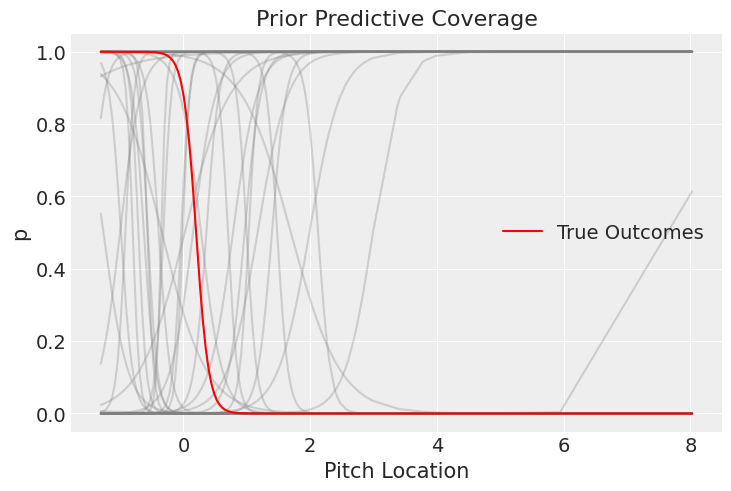

In [ ]:
# Get the prior predictive probabilities

p_prior = idata.prior["p"].values  # shape: (draws, obs)

X_sorted_idx = np.argsort(df['pitch_location'])
X_sorted = df['pitch_location'].values[X_sorted_idx]
true_sorted = true_p[X_sorted_idx]

# p_prior_sorted = p_prior[:, X_sorted_idx]

for sig in idata.prior['p'].values[0]:
    # Sort data
    sig_sort = sig[X_sorted_idx]
    # Plot data
    plt.plot(X_sorted, sig_sort, color='gray', alpha=0.3)


# plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

plt.plot(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

plt.xlabel("Pitch Location")
plt.ylabel("p")
plt.title("Prior Predictive Coverage")
plt.legend()
plt.show()

### Real model using pitch location

Getting advi samples...


Output()

Tracing mean field...
Plotting posterior...


<Axes: title={'center': 'pitch_location'}>

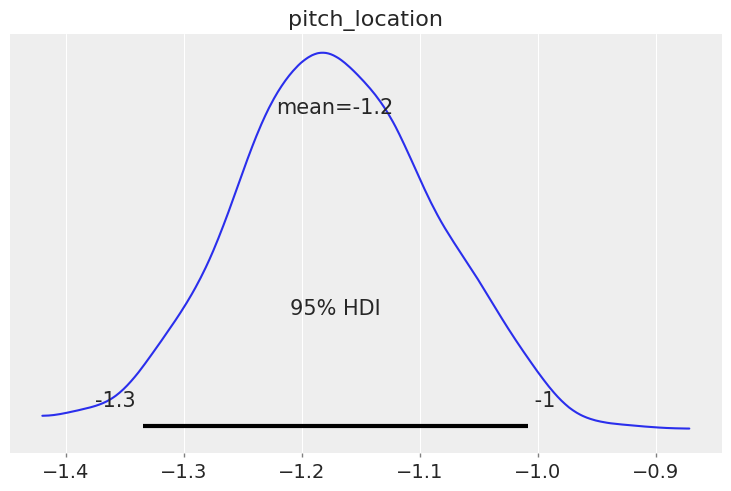

In [ ]:
# Create real model, pitch_location
with pm.Model() as m_locaiton:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pitch_location = pm.Normal("pitch_location", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (pitch_location*df['pitch_location'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    print("Getting advi samples...")
    mean_field = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata1 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata1.extend(pm.sample_posterior_predictive(idata1))
    # loocv_ump1["m1"] = idata1

print("Tracing mean field...")
trace_advi1 = mean_field.sample(1000)

# add to model comparision dict
loocv_ump1["locaiton"] = trace_advi1

print("Plotting posterior...")
az.plot_posterior(trace_advi1, var_names=["pitch_location"], hdi_prob=0.95)

## 1) Type of pitch
- pitch_type (binary for each type)

Output()

array([<Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'changeup'}>,
       <Axes: title={'center': 'off_speed'}>,
       <Axes: title={'center': 'rare'}>], dtype=object)

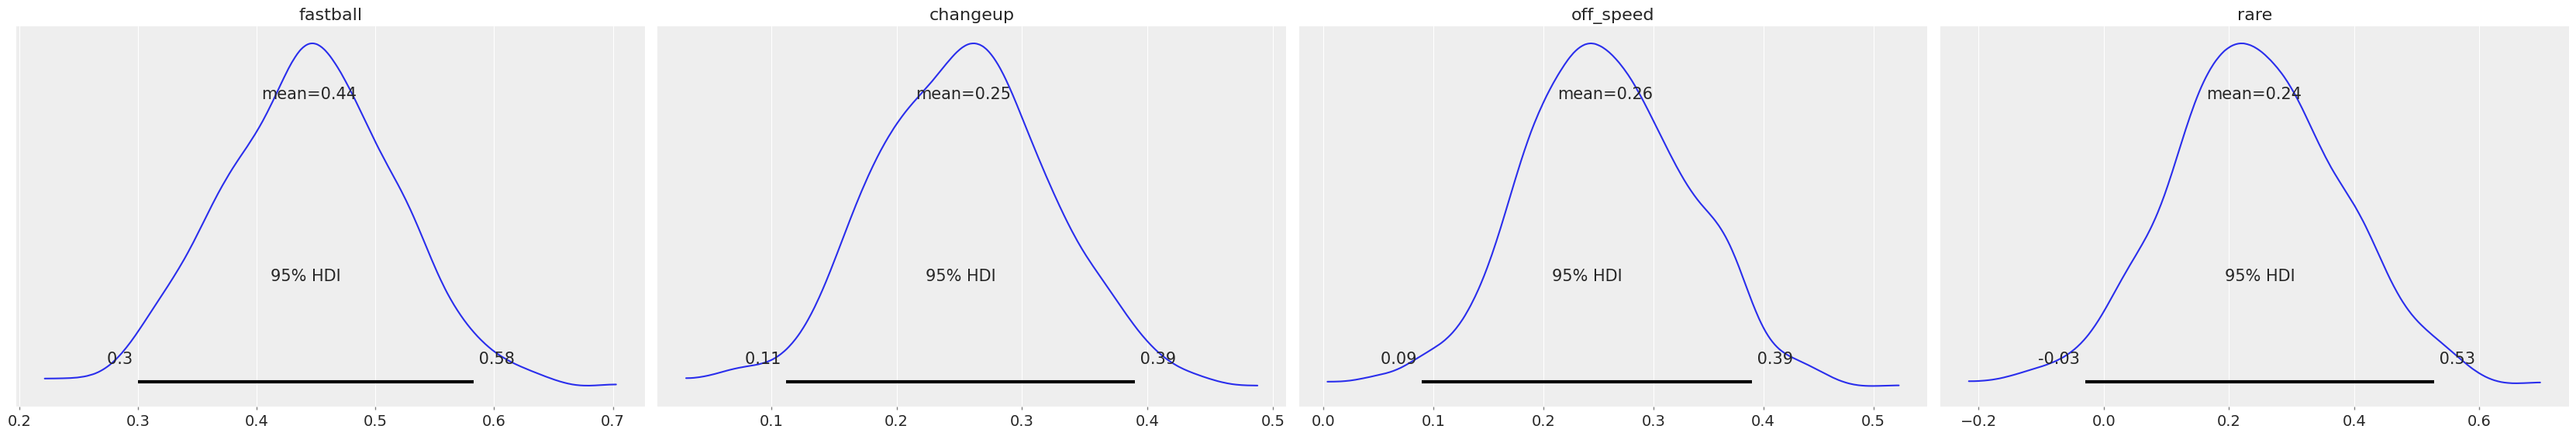

In [ ]:
with pm.Model() as pitch_type:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    fastball = pm.Normal("fastball", mu=0, sigma=10)
    changeup = pm.Normal("changeup", mu=0, sigma=10)
    off_speed = pm.Normal("off_speed", mu=0, sigma=10)
    rare = pm.Normal("rare", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (fastball*df['fastball']) + (off_speed*df['off_speed']) + (changeup*df['changeup']) + (rare*df['rare'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field2 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_advi2 = mean_field2.sample(1000)

# add to model comparision dict
loocv_ump1["pitch_type"] = trace_advi2

az.plot_posterior(trace_advi2, var_names=["fastball", "changeup", 'off_speed', 'rare'], hdi_prob=0.95)

# 2) Count
- Balls, strikes, pitch_number, at_bat_number, description

Output()

array([<Axes: title={'center': 'balls'}>,
       <Axes: title={'center': 'strikes'}>,
       <Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'description'}>], dtype=object)

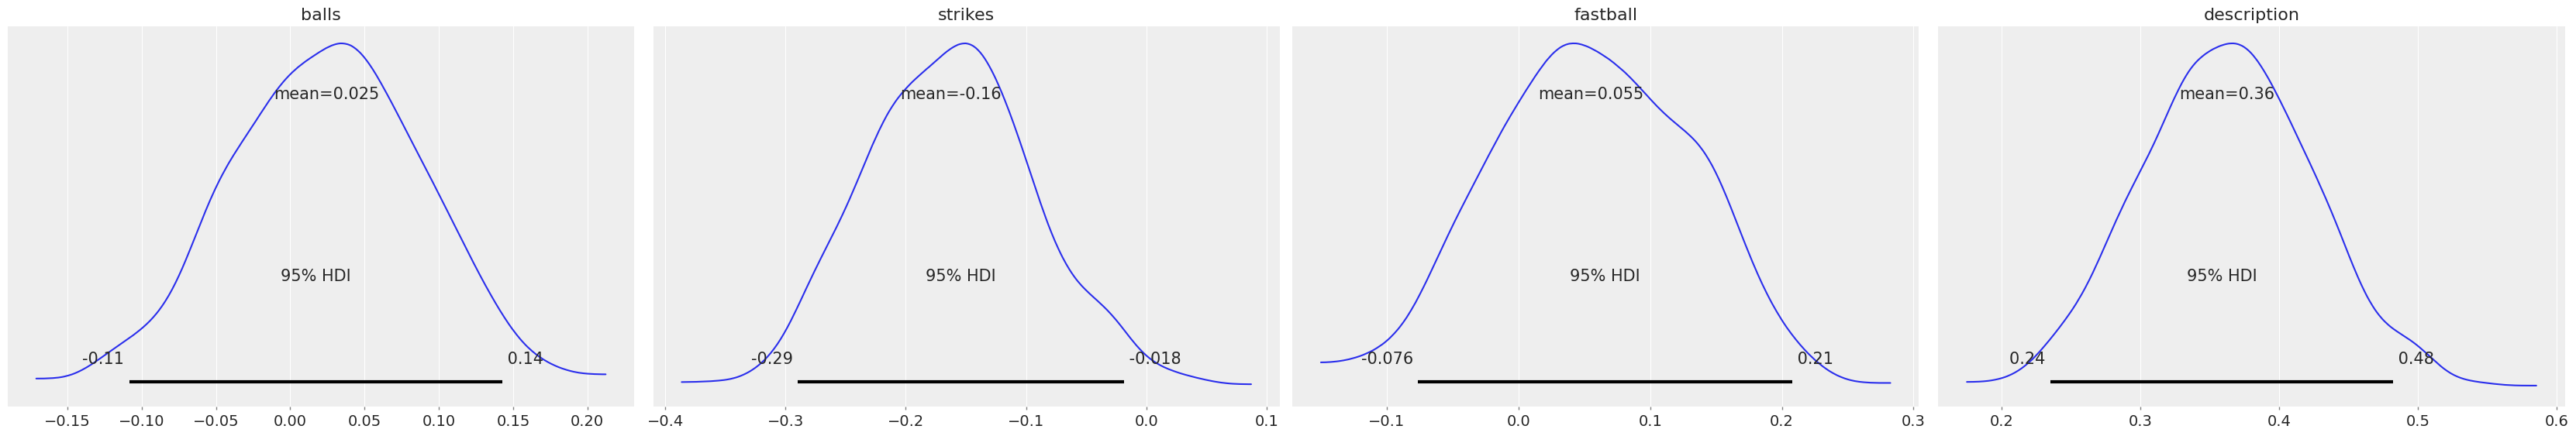

In [ ]:
# Create first model looking at count
# balls, strikes, pitch type, description (called ball: 0, or strike: 1)
with pm.Model() as count:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    balls = pm.Normal("balls", mu=0, sigma=10)
    strikes = pm.Normal("strikes", mu=0, sigma=10)
    fastball = pm.Normal("fastball", mu=0, sigma=10)
    description = pm.Normal("description", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (balls*df['balls']) + (strikes*df['strikes']) + (fastball*df['fastball']) + (description*df['description'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field5 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_advi5 = mean_field5.sample(1000)

# add to model comparision dict
loocv_ump1["count"] = trace_advi5

az.plot_posterior(trace_advi5, var_names=["balls", 'strikes', 'fastball', 'description'], hdi_prob=0.95)

# 3) Pitch characteristics
- plate_z, plate_x, release_speed, release_pos_x, release_pos_z, release_pos_y, pitch_location

Output()

array([[<Axes: title={'center': 'release_speed'}>,
        <Axes: title={'center': 'release_pos_x'}>,
        <Axes: title={'center': 'release_pos_z'}>],
       [<Axes: title={'center': 'release_pos_y'}>,
        <Axes: title={'center': 'plate_z'}>,
        <Axes: title={'center': 'plate_x'}>],
       [<Axes: title={'center': 'pitch_location'}>, <Axes: >, <Axes: >]],
      dtype=object)

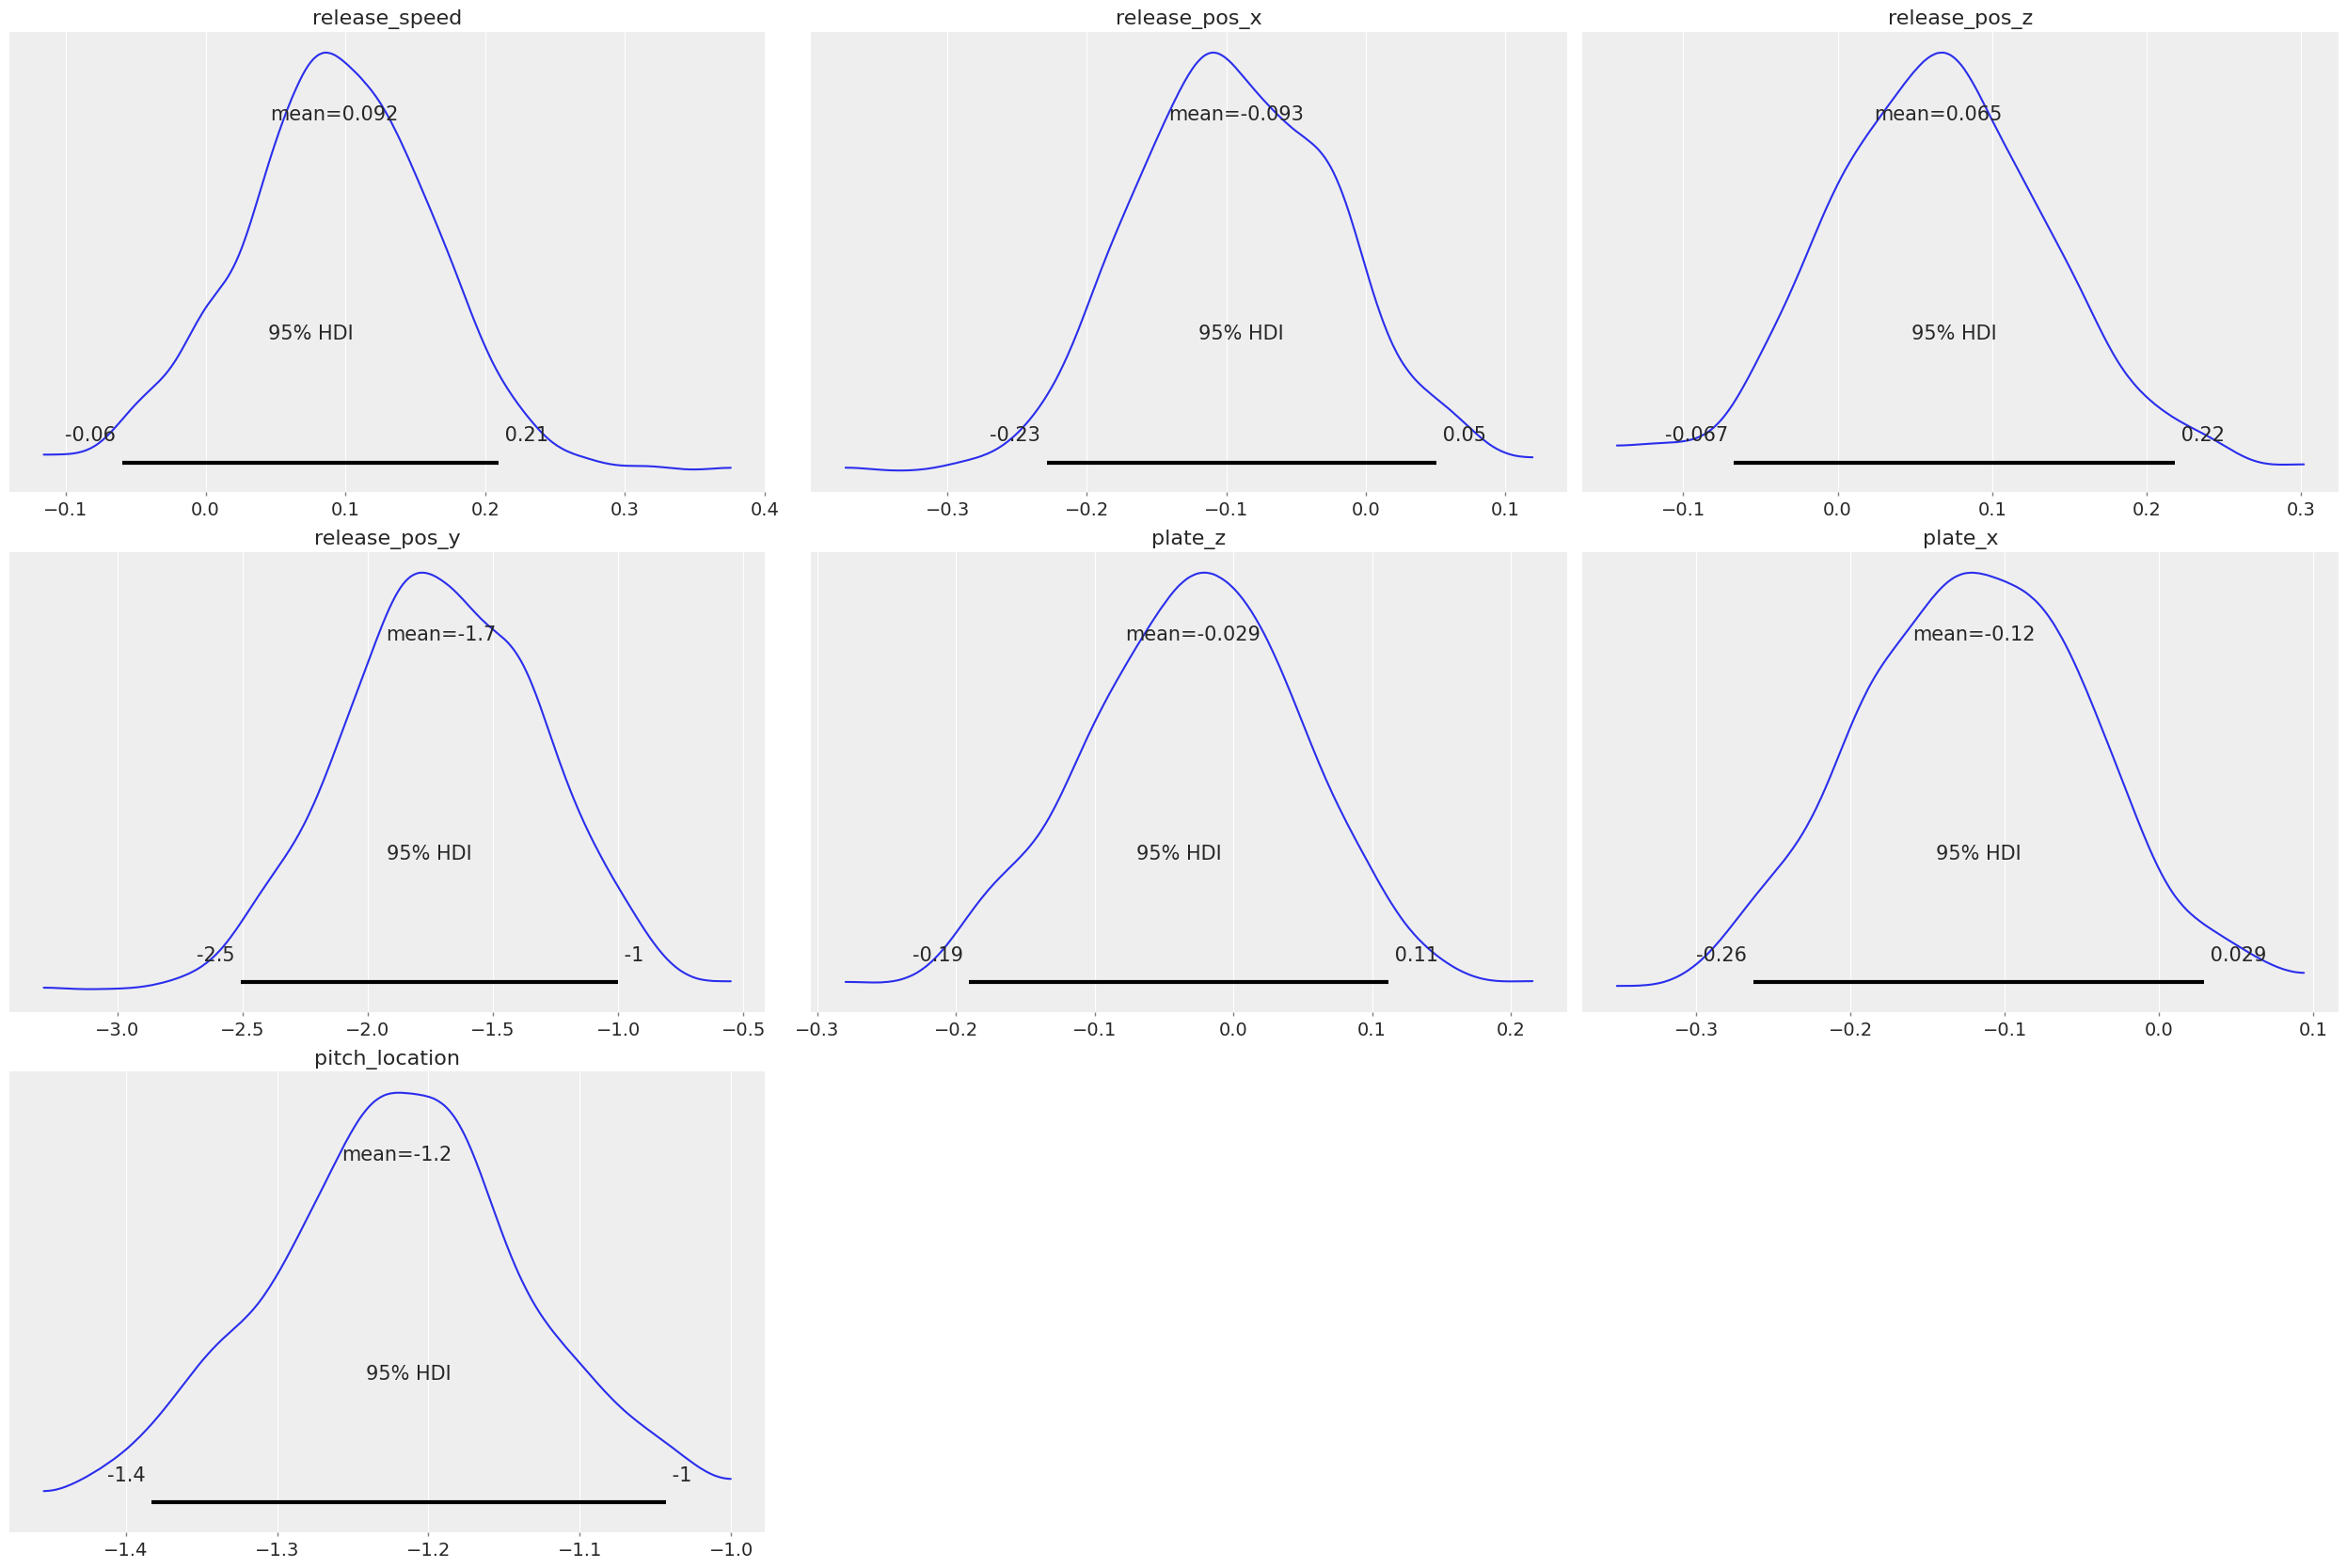

In [ ]:
with pm.Model() as pitch_characteristics:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    release_speed = pm.Normal("release_speed", mu=0, sigma=10)
    release_pos_x = pm.Normal("release_pos_x", mu=0, sigma=10)
    release_pos_z = pm.Normal("release_pos_z", mu=0, sigma=10)
    release_pos_y = pm.Normal("release_pos_y", mu=0, sigma=10)
    pitch_location = pm.Normal("pitch_location", mu=0, sigma=10)
    plate_z = pm.Normal("plate_z", mu=0, sigma=10)
    plate_x = pm.Normal("plate_x", mu=0, sigma=10)


    # Likelihood
    mu = intercept + (
        (release_speed*df['release_speed']) + (release_pos_x*df['release_pos_x']) + (release_pos_z*df['release_pos_z']) + (release_pos_y*df['release_pos_y'])
        + (pitch_location*df['pitch_location']) + (plate_z*df['plate_z']) + (plate_x*df['plate_x'])
    )
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field3 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_advi3 = mean_field3.sample(1000)

# add to model comparision dict
loocv_ump1["pitch_characteristics"] = trace_advi3

- plate_z, plate_x, release_speed, release_pos_x, release_pos_z, release_pos_y, pitch_location
az.plot_posterior(trace_advi3, var_names=["release_speed", 'release_pos_x', 'release_pos_z', 'release_pos_y', 'plate_z', 'plate_x', 'pitch_location'], hdi_prob=0.95)

# 4) Movement and velocity profile:
- pfx_x, pfx_z, vx0, vy0, vz0, ax, ay, az

Output()

array([[<Axes: title={'center': 'pfx_x'}>,
        <Axes: title={'center': 'pfx_z'}>,
        <Axes: title={'center': 'vx0'}>, <Axes: title={'center': 'vy0'}>],
       [<Axes: title={'center': 'vz0'}>,
        <Axes: title={'center': 'accx'}>,
        <Axes: title={'center': 'accy'}>,
        <Axes: title={'center': 'accz'}>]], dtype=object)

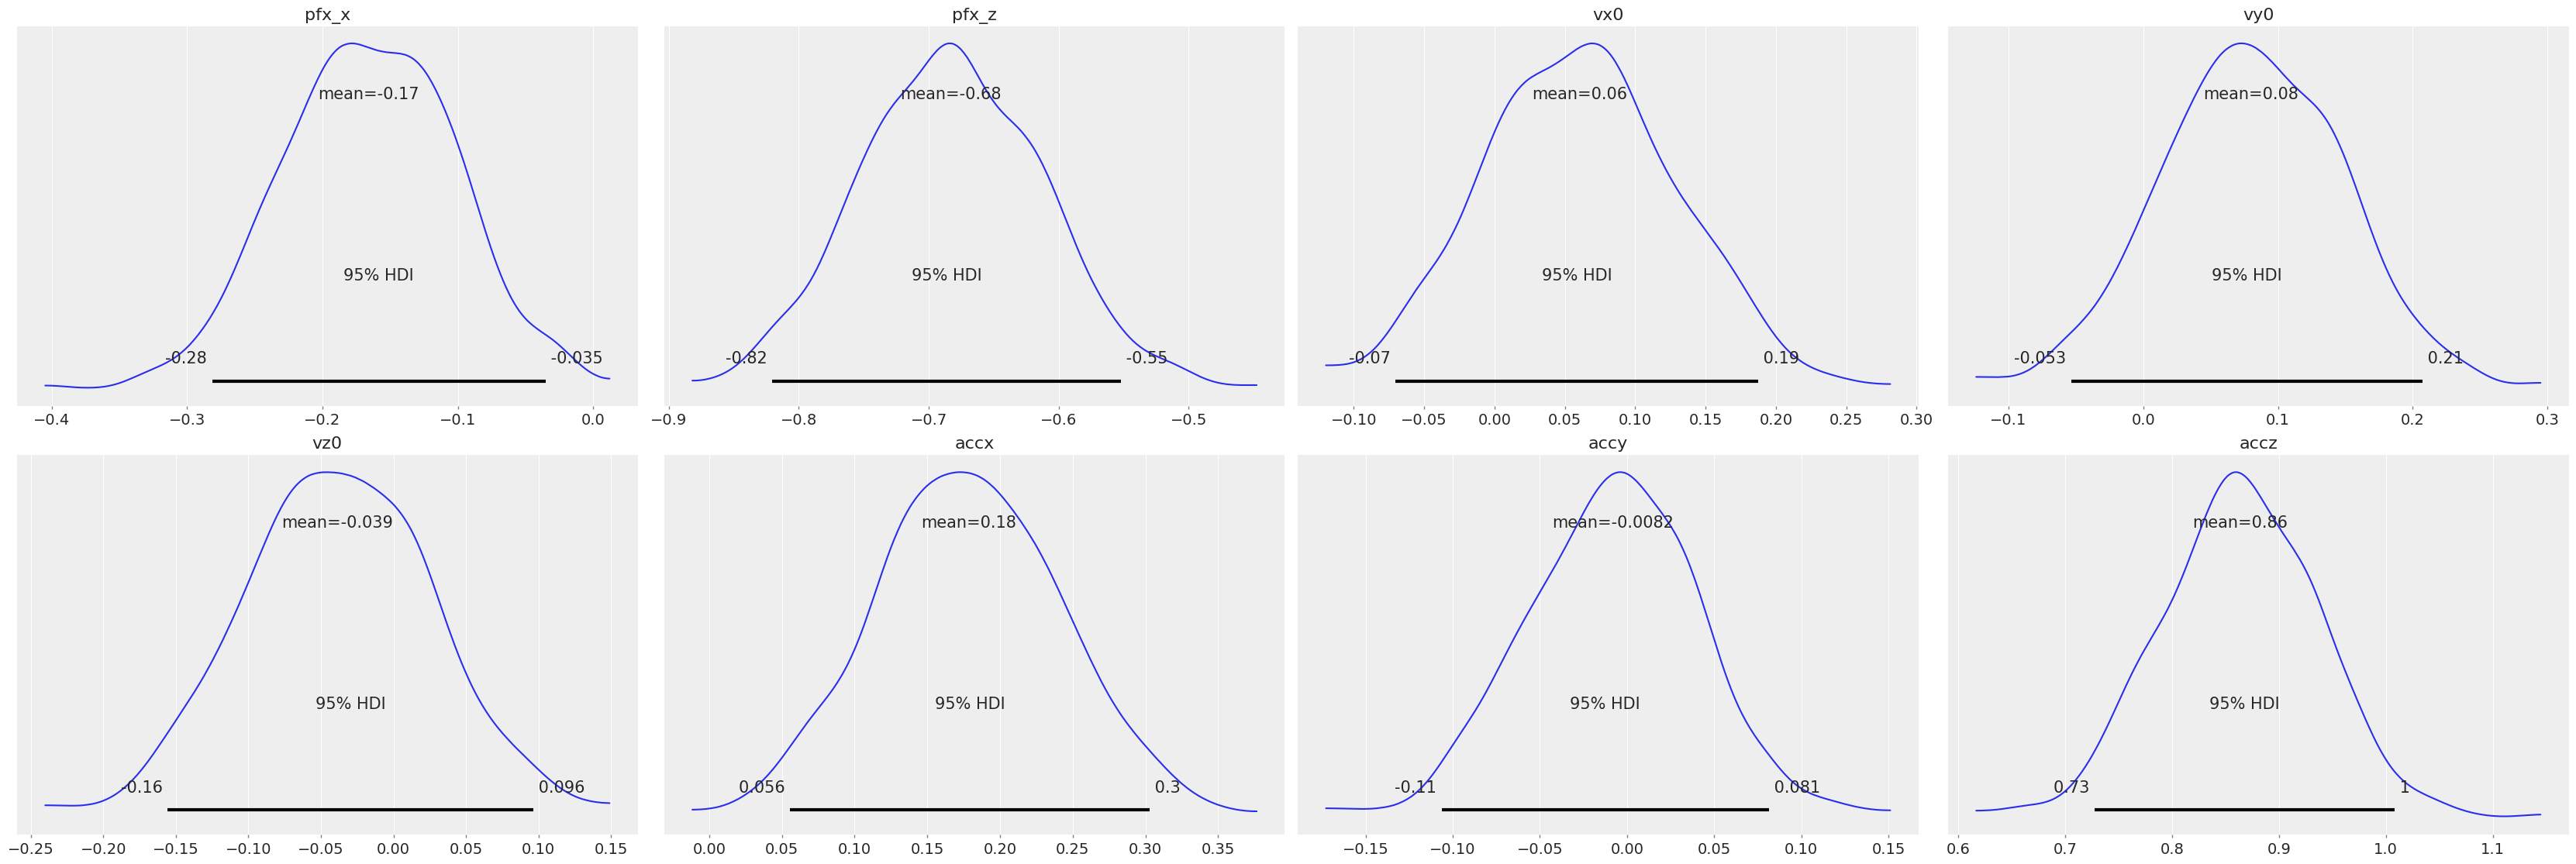

In [ ]:
# pfx_x: Horizontal movement in feet from the catcher's perspective.
# pfx_z: Vertical movement in feet from the catcher's perspective.
# vx0: Velocity of the pitch in the x-dimension (feet/sec), determined at y=50 feet.
# vy0: Velocity of the pitch in the y-dimension (feet/sec), determined at y=50 feet.
# vz0: Velocity of the pitch in the z-dimension (feet/sec), determined at y=50 feet.
# ax: Acceleration of the pitch in the x-dimension (feet/sec²), determined at y=50 feet.
# ay: Acceleration of the pitch in the y-dimension (feet/sec²), determined at y=50 feet.
# az: Acceleration of the pitch in the z-dimension (feet/sec²), determined at y=50 feet.

# movement
with pm.Model() as profile:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pfx_x = pm.Normal("pfx_x", mu=0, sigma=10)
    pfx_z = pm.Normal("pfx_z", mu=0, sigma=10)
    vx0 = pm.Normal("vx0", mu=0, sigma=10)
    vy0 = pm.Normal("vy0", mu=0, sigma=10)
    vz0 = pm.Normal("vz0", mu=0, sigma=10)
    accx = pm.Normal("accx", mu=0, sigma=10)
    accy = pm.Normal("accy", mu=0, sigma=10)
    accz = pm.Normal("accz", mu=0, sigma=10)


    # Likelihood
    mu = intercept + (pfx_x*df['pfx_x']) + (pfx_z*df['pfx_z']) + (vx0*df['vx0']) + (vy0*df['vy0']) + (vz0*df['vz0']) + (accx*df['ax']) + (accy*df['ay']) + (accz*df['az'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field4 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_advi4 = mean_field4.sample(1000)

# add to model comparision dict
loocv_ump1["profile"] = trace_advi4

# Plot posterior
az.plot_posterior(trace_advi4, var_names=['pfx_x', 'pfx_z', 'vx0', 'vy0', 'vz0', 'accx', 'accy', 'accz'], hdi_prob=0.95)

Output()

array([<Axes: title={'center': 'pfx_x'}>,
       <Axes: title={'center': 'pfx_z'}>,
       <Axes: title={'center': 'accx'}>, <Axes: title={'center': 'accz'}>],
      dtype=object)

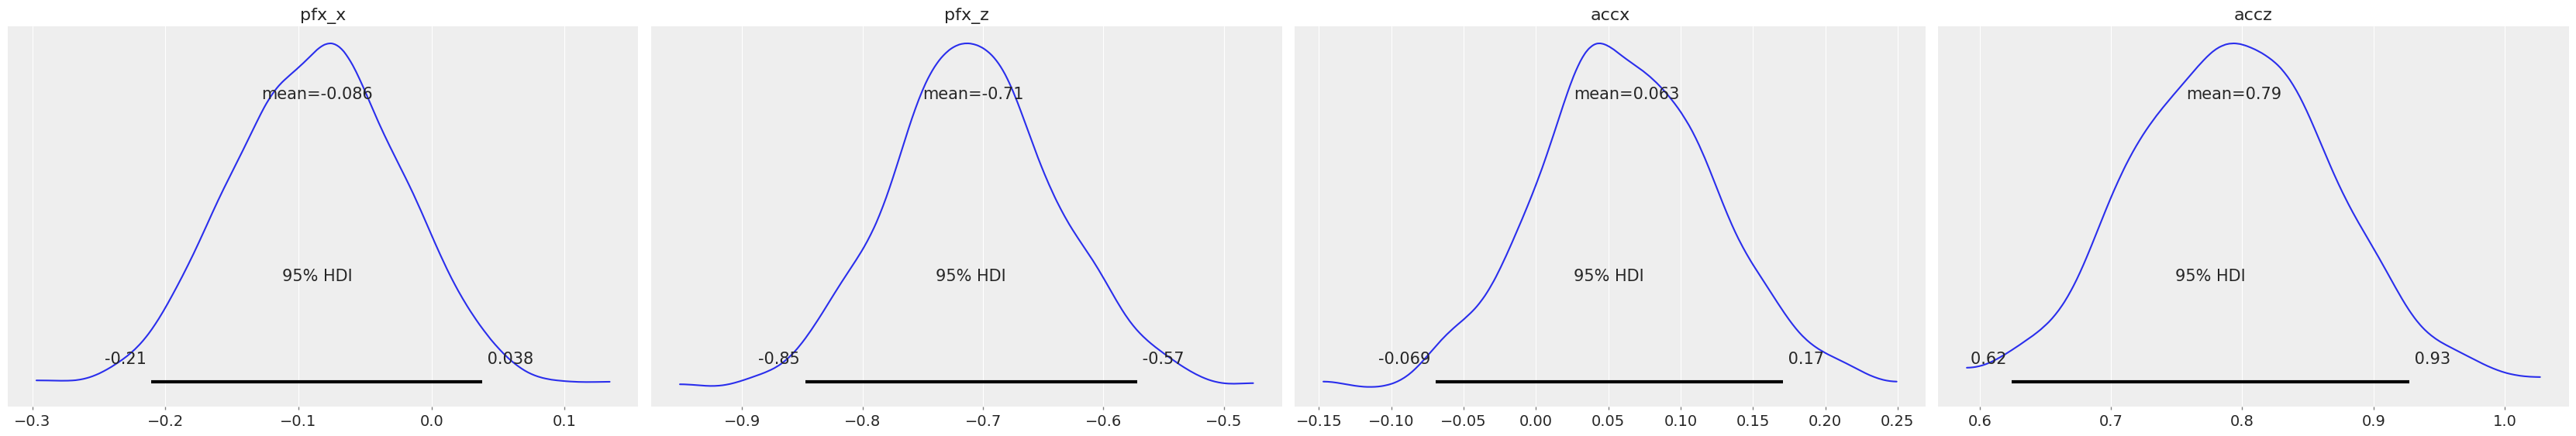

In [ ]:
# do it again but just with impact variables
with pm.Model() as profile_1:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pfx_x = pm.Normal("pfx_x", mu=0, sigma=10)
    pfx_z = pm.Normal("pfx_z", mu=0, sigma=10)
    accx = pm.Normal("accx", mu=0, sigma=10)
    accz = pm.Normal("accz", mu=0, sigma=10)


    # Likelihood
    mu = intercept + (pfx_x*df['pfx_x']) + (pfx_z*df['pfx_z']) + (accx*df['ax']) + (accz*df['az'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field4_1 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_advi4_1 = mean_field4_1.sample(1000)

# add to model comparision dict
loocv_ump1["profile"] = trace_advi4_1

# Plot posterior
az.plot_posterior(trace_advi4_1, var_names=['pfx_x', 'pfx_z', 'accx', 'accz'], hdi_prob=0.95)

# 1) Important Situation
- delta_home_win_exp, delta_run_exp, home_score, away_score, on_3b/2/1

Output()

array([[<Axes: title={'center': 'delta_home_win_exp'}>,
        <Axes: title={'center': 'delta_run_exp'}>,
        <Axes: title={'center': 'home_score'}>],
       [<Axes: title={'center': 'away_score'}>,
        <Axes: title={'center': 'on_3b'}>,
        <Axes: title={'center': 'on_2b'}>],
       [<Axes: title={'center': 'on_1b'}>, <Axes: >, <Axes: >]],
      dtype=object)

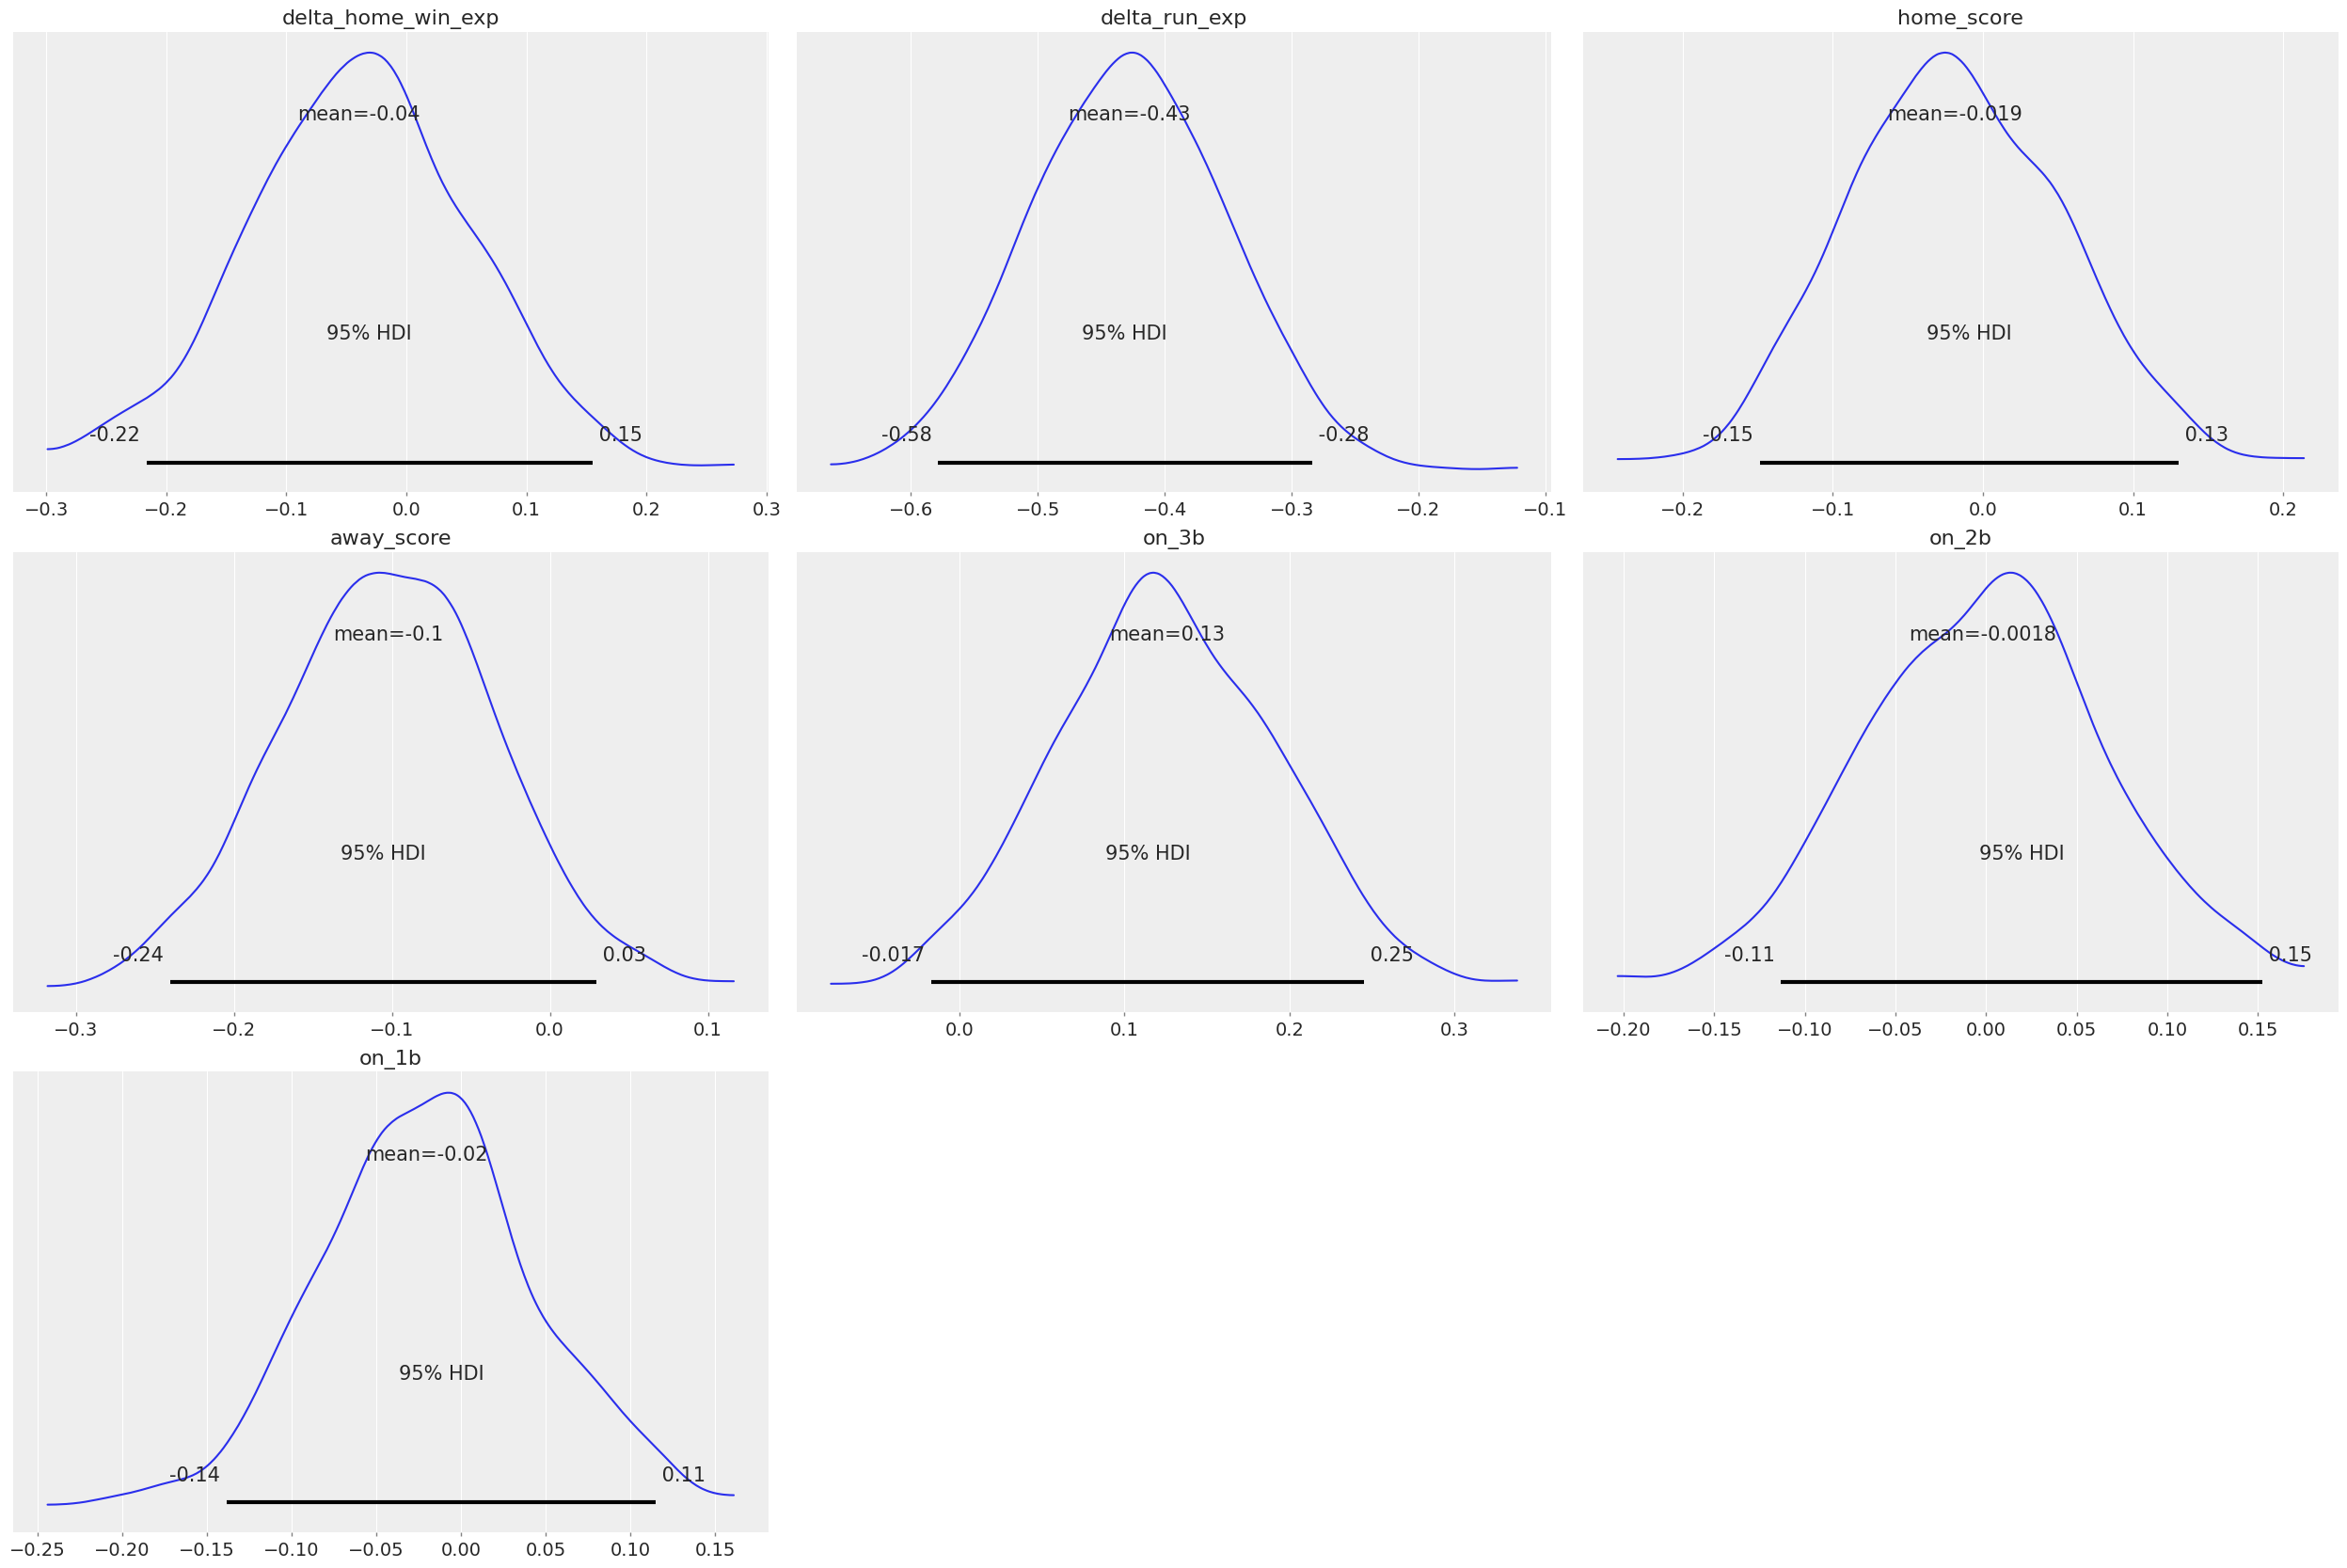

In [ ]:
# imp sit model
with pm.Model() as situation:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    delta_home_win_exp = pm.Normal("delta_home_win_exp", mu=0, sigma=10)
    delta_run_exp = pm.Normal("delta_run_exp", mu=0, sigma=10)
    home_score = pm.Normal("home_score", mu=0, sigma=10)
    away_score = pm.Normal("away_score", mu=0, sigma=10)
    on_3b = pm.Normal("on_3b", mu=0, sigma=10)
    on_2b = pm.Normal("on_2b", mu=0, sigma=10)
    on_1b = pm.Normal("on_1b", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (
        (delta_home_win_exp*df['delta_home_win_exp']) + (delta_run_exp*df['delta_run_exp']) + (home_score*df['home_score']) +
        (away_score*df['away_score']) + (on_3b*df['on_3b']) + (on_2b*df['on_2b']) + (on_1b*df['on_1b'])
    )
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field6 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_advi6 = mean_field6.sample(1000)

# add to model comparision dict
loocv_ump1["situation"] = trace_advi6

az.plot_posterior(trace_advi6, var_names=["delta_home_win_exp", 'delta_run_exp', 'home_score', 'away_score', 'on_3b', 'on_2b', 'on_1b'], hdi_prob=0.95)

6) Dimentions of pitcher and hitter
- all_star_player, sz_bot, sz_top, stand, p_throws, stand

In [ ]:
# player dimentions model
loocv_ump1 = {}
with pm.Model() as situation:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    all_star_player = pm.Normal("all_star_player", mu=0, sigma=10)
    sz_bot = pm.Normal("sz_bot", mu=0, sigma=10)
    sz_top = pm.Normal("sz_top", mu=0, sigma=10)
    p_throws = pm.Normal("p_throws", mu=0, sigma=10)
    stand = pm.Normal("stand", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (all_star_player*df['all_star_player']) + (sz_bot*df['sz_bot']) + (sz_top*df['sz_top']) + (p_throws*df['p_throws']) + (stand*df['stand'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field6 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_advi6 = mean_field6.sample(1000)

# add to model comparision dict
loocv_ump1["situation"] = trace_advi6

az.plot_posterior(trace_advi6, var_names=['all_star_player', 'sz_bot', 'sz_top', 'p_throws', 'stand'], hdi_prob=0.95)

Output()

TypeError: to_inference_data() got an unexpected keyword argument 'idata_kwargs'

# Compare Models

In [ ]:
cmp = az.compare(loocv_ump1)
az.plot_compare(cmp, figsize=(20, 9))
# plt.savefig('model_comparison.svg')

TypeError: Encountered error in ELPD computation of compare.